# Polynomial Trajectory Straightening in Multi-AE Latent Spaces

**Hypothesis (from the perceptual straightening paper):** Natural video trajectories curve through latent/perceptual space. Fitting a low-degree polynomial to the sequence of latent embeddings and decoding the smoothed curve produces more temporally coherent output with reduced motion jitter.

**This notebook:**
1. Generates frames via Stable Video Diffusion (SVD-XT).
2. Encodes all frames with **three off-the-shelf AutoencoderKL** variants (SD-1.5, SDXL, PixArt/SD-2.x).
3. Fits polynomial regressors of degree **2, 3, 4, 5** to the latent trajectories — *all regression is done in latent space*.
4. Decodes the smoothed latent curves back to pixel frames and saves as GIFs.
5. Computes trajectory straightness, temporal SSIM, pixel temporal difference (PTD), and curvature, and produces comparison plots and a summary table.

In [1]:
# ============================================================
# CELL 1 — Imports, Config, Output Directories
# ============================================================
import os, json, gc, warnings
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

warnings.filterwarnings("ignore")

# ── hardware ────────────────────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE  = torch.float16   # fp16 throughout; linalg done in fp32

# ── SVD generation settings (2 s @ 7 fps = 14 frames) ──────
SVD_MODEL   = "stabilityai/stable-video-diffusion-img2vid-xt"
NUM_FRAMES  = 14          # enough points for degree-5 fit (need > deg+1)
FPS_ID      = 7           # gives 2 s GIF
HEIGHT, WIDTH = 256, 256  # small for RTX 4060 VRAM budget
SVD_STEPS   = 25
MOTION_BUCKET = 127
NOISE_AUG   = 0.02

# ── autoencoders to compare ─────────────────────────────────
AE_CONFIGS = {
    "sd15":   "runwayml/stable-diffusion-v1-5",
    "sdxl":   "stabilityai/stable-diffusion-xl-base-1.0",
    "pixart": "PixArt-alpha/PixArt-XL-2-256x256",
}

# ── polynomial degrees to sweep ─────────────────────────────
POLY_DEGREES = [2, 3, 4, 5]

# ── output ───────────────────────────────────────────────────
OUT_ROOT = "experiment-results-comp"
for sub in ["gifs", "plots", "metrics"]:
    os.makedirs(os.path.join(OUT_ROOT, sub), exist_ok=True)

HF_TOKEN_PATH = "hf-access-token.txt"
hf_token = open(HF_TOKEN_PATH).read().strip() if os.path.exists(HF_TOKEN_PATH) else None

print(f"Device: {DEVICE}  |  dtype: {DTYPE}")
print(f"Frames: {NUM_FRAMES}  |  FPS: {FPS_ID}  |  Resolution: {HEIGHT}×{WIDTH}")
print(f"AE models: {list(AE_CONFIGS.keys())}")
print(f"Poly degrees: {POLY_DEGREES}")
print("Output dir:", OUT_ROOT)


Device: cuda  |  dtype: torch.float16
Frames: 14  |  FPS: 7  |  Resolution: 256×256
AE models: ['sd15', 'sdxl', 'pixart']
Poly degrees: [2, 3, 4, 5]
Output dir: experiment-results-comp


In [7]:
# ============================================================
# CELL 2 — Helpers: polynomial regression, metrics, GIF save
# ============================================================

# ── polynomial regression in latent space ───────────────────
def poly_regression_latent(latent_seq: torch.Tensor, degree: int) -> torch.Tensor:
    """
    Fit a polynomial of `degree` to the (N, *spatial) latent sequence
    using ordinary least squares in float32, then return smoothed
    latents cast back to the original dtype.

    latent_seq: (N, C, H, W)  — sequence of N latent frames
    Returns   : (N, C, H, W)  — polynomial-smoothed latents
    """
    N = latent_seq.shape[0]
    num_params = degree + 1  # e.g. degree=2 → [1, t, t²]
    assert N > num_params, (
        f"Need more frames than poly params: N={N}, params={num_params}"
    )
    orig_dtype = latent_seq.dtype
    dev = latent_seq.device

    # Build Vandermonde matrix A  (N × num_params), always float32
    t = torch.linspace(0.0, 1.0, N, device=dev, dtype=torch.float32).unsqueeze(1)  # (N,1)
    powers = [t ** i for i in range(num_params)]                                    # list of (N,1)
    A = torch.cat(powers, dim=1)                                                    # (N, num_params)

    # Flatten latents: (N, D) in float32
    flat = latent_seq.reshape(N, -1).to(torch.float32)

    # OLS:  coeffs = (AᵀA)⁻¹ Aᵀ flat    shape: (num_params, D)
    # Use torch.linalg.lstsq for numerical stability (no explicit inverse)
    # driver='gelsd' works on CPU; 'gels' on CUDA
    driver = "gels" if dev.type == "cuda" else "gelsd"
    result = torch.linalg.lstsq(A, flat, driver=driver)
    coeffs = result.solution  # (num_params, D)

    # Reconstruct: Â·coeffs
    smoothed_flat = A @ coeffs                     # (N, D)
    smoothed = smoothed_flat.reshape(latent_seq.shape).to(orig_dtype)
    return smoothed


# ── trajectory metrics ───────────────────────────────────────
import scipy.linalg

def pca_2d(arr: np.ndarray) -> np.ndarray:
    """Project (N, D) array to 2D via PCA."""
    # 1. Sanitize the array: Check for NaNs or Infs
    if not np.isfinite(arr).all():
        print("\n  [Warning] NaN/Inf detected in latents! Replacing with 0s to prevent SVD crash.")
        arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
        
    centered = arr - arr.mean(axis=0, keepdims=True)
    
    # 2. Compute SVD with a fallback driver
    try:
        _, _, vh = np.linalg.svd(centered, full_matrices=False)
    except np.linalg.LinAlgError:
        print("\n  [Warning] np.linalg.svd failed to converge. Falling back to scipy 'gesvd' driver.")
        # 'gesvd' is slower but numerically much more stable than the default 'gesdd'
        _, _, vh = scipy.linalg.svd(centered, full_matrices=False, lapack_driver='gesvd')
        
    return centered @ vh[:2].T

def trajectory_straightness(traj_2d: np.ndarray) -> float:
    """Mean cosine similarity of consecutive displacement vectors."""
    if len(traj_2d) < 3:
        return float("nan")
    d = np.diff(traj_2d, axis=0)
    n = d / (np.linalg.norm(d, axis=1, keepdims=True) + 1e-8)
    return float(np.mean(np.sum(n[:-1] * n[1:], axis=1)))


def latent_curvature(latent_seq: torch.Tensor) -> float:
    """Mean angular curvature in latent space (radians)."""
    flat = latent_seq.reshape(len(latent_seq), -1).float()
    d = flat[1:] - flat[:-1]
    dn = torch.nn.functional.normalize(d, dim=1)
    cos = torch.clamp((dn[:-1] * dn[1:]).sum(dim=1), -1 + 1e-6, 1 - 1e-6)
    return torch.acos(cos).mean().item()


def frames_to_numpy(frames):
    """List[PIL.Image] → float32 numpy (N, H, W, 3) in [0,1]."""
    return np.stack([np.array(f.convert("RGB"), dtype=np.float32) / 255.0 for f in frames])


def temporal_ssim_ptd(frames_np: np.ndarray):
    """Compute per-pair SSIM (simple) and pixel temporal difference."""
    ssims, ptds = [], []
    for i in range(len(frames_np) - 1):
        a, b = frames_np[i], frames_np[i + 1]
        ptds.append(float(np.mean(np.abs(a - b)) * 255.0))
        # lightweight SSIM (no skimage dependency)
        ag = a.mean(-1); bg = b.mean(-1)
        mu_a, mu_b = ag.mean(), bg.mean()
        var_a = ag.var(); var_b = bg.var()
        cov = float(np.mean((ag - mu_a) * (bg - mu_b)))
        c1, c2 = 0.01**2, 0.03**2
        ssim = ((2*mu_a*mu_b + c1)*(2*cov + c2)) / \
               ((mu_a**2 + mu_b**2 + c1)*(var_a + var_b + c2) + 1e-12)
        ssims.append(float(ssim))
    return float(np.mean(ssims)), float(np.mean(ptds))


# ── GIF utilities ────────────────────────────────────────────
def tensor_to_pil(t: torch.Tensor) -> Image.Image:
    """(C, H, W) float16/32 tensor in [-1,1] → PIL Image."""
    t = t.float().clamp(-1, 1)
    arr = ((t + 1) / 2 * 255).byte().permute(1, 2, 0).cpu().numpy()
    return Image.fromarray(arr)


def save_gif(pil_frames, path: str, fps: int = 7):
    duration_ms = int(1000 / fps)
    pil_frames[0].save(
        path,
        save_all=True,
        append_images=pil_frames[1:],
        loop=0,
        duration=duration_ms,
        optimize=False,
    )


print("Helper functions defined.")

# Shared palette used by multiple plot cells
DEGREE_COLORS = {2: "#e63946", 3: "#2a9d8f", 4: "#e9c46a", 5: "#457b9d"}


Helper functions defined.


In [3]:
# ============================================================
# CELL 3 — Generate frames with Stable Video Diffusion
# Produces: svd_frames (list of PIL), baseline GIF
# ============================================================
from diffusers import StableVideoDiffusionPipeline
from diffusers.utils import load_image
import requests
from io import BytesIO

# ── seed image: use local starting_frame.png if available ───
SEED_IMAGE_PATH = os.path.join("experimental-results", "starting_frame.png")
if os.path.exists(SEED_IMAGE_PATH):
    seed_pil = Image.open(SEED_IMAGE_PATH).convert("RGB").resize((WIDTH, HEIGHT))
    print(f"Loaded starting image from {SEED_IMAGE_PATH}")
else:
    SEED_IMAGE_URL = (
        "https://huggingface.co/datasets/huggingface/documentation-images/"
        "resolve/main/diffusers/svd/rocket.png"
    )
    try:
        resp = requests.get(SEED_IMAGE_URL, timeout=30)
        seed_pil = Image.open(BytesIO(resp.content)).convert("RGB").resize((WIDTH, HEIGHT))
        print("Downloaded fallback seed image.")
    except Exception as e:
        print(f"Could not fetch seed image ({e}); generating a synthetic gradient.")
        arr = np.zeros((HEIGHT, WIDTH, 3), dtype=np.uint8)
        arr[..., 0] = np.linspace(30, 200, WIDTH, dtype=np.uint8)
        arr[..., 2] = np.linspace(200, 30, HEIGHT, dtype=np.uint8)[:, None]
        seed_pil = Image.fromarray(arr)

seed_pil.save(os.path.join(OUT_ROOT, "seed_image.png"))
print("Seed image ready:", seed_pil.size)

# ── load SVD-XT ──────────────────────────────────────────────
print("Loading SVD-XT pipeline …")
if hf_token is None:
    print("No HF token found; using anonymous access (may be slower).")
else:
    print("Using HF token from hf-access-token.txt")

svd_pipe = StableVideoDiffusionPipeline.from_pretrained(
    SVD_MODEL,
    torch_dtype=DTYPE,
    token=hf_token,
)
svd_pipe = svd_pipe.to(DEVICE)
svd_pipe.enable_attention_slicing()

# ── run inference ────────────────────────────────────────────
print(f"Running SVD inference ({NUM_FRAMES} frames, {SVD_STEPS} steps) …")
generator = torch.Generator(device=DEVICE).manual_seed(42)

with torch.inference_mode():
    result = svd_pipe(
        seed_pil,
        num_frames=NUM_FRAMES,
        num_inference_steps=SVD_STEPS,
        fps=FPS_ID,
        motion_bucket_id=MOTION_BUCKET,
        noise_aug_strength=NOISE_AUG,
        height=HEIGHT,
        width=WIDTH,
        generator=generator,
        output_type="pil",
    )

svd_frames: list = result.frames[0]   # list of NUM_FRAMES PIL Images
assert len(svd_frames) == NUM_FRAMES

# ── save baseline GIF ────────────────────────────────────────
baseline_gif = os.path.join(OUT_ROOT, "gifs", "baseline.gif")
save_gif(svd_frames, baseline_gif, fps=FPS_ID)
print(f"Baseline GIF saved → {baseline_gif}")

# ── free SVD from GPU ──────────────────────────────────────
del svd_pipe
gc.collect()
torch.cuda.empty_cache()
print("SVD unloaded from GPU.")


Downloaded fallback seed image.
Seed image ready: (256, 256)
Loading SVD-XT pipeline …
Using HF token from hf-access-token.txt


Loading pipeline components...: 100%|██████████| 5/5 [00:09<00:00,  1.94s/it]


Running SVD inference (14 frames, 25 steps) …


100%|██████████| 25/25 [00:12<00:00,  1.95it/s]


Baseline GIF saved → experiment-results-comp\gifs\baseline.gif
SVD unloaded from GPU.


In [10]:
# ============================================================
# CELL 4 — Load three AutoencoderKL models (vae only)
# We extract only the VAE submodule to save VRAM.
# ============================================================
from diffusers import AutoencoderKL

def load_vae(repo_id: str, token=None) -> AutoencoderKL:
    """Load AutoencoderKL from a Diffusers pipeline repo or standalone."""
    vae = AutoencoderKL.from_pretrained(
        repo_id,
        subfolder="vae",
        # Force float32 specifically for the VAE to prevent NaN overflow
        torch_dtype=torch.float32, 
        token=token,
    )
    vae = vae.to(DEVICE).eval()
    for p in vae.parameters():
        p.requires_grad_(False)
    return vae


# Pre-process SVD frames → (N, 3, H, W) fp16 tensor in [-1, 1]
import torchvision.transforms.functional as TF

def pil_list_to_tensor(pil_frames, height, width, device, dtype):
    tensors = []
    for img in pil_frames:
        img_resized = img.resize((width, height), Image.LANCZOS)
        t = TF.to_tensor(img_resized).to(dtype=dtype, device=device)  # [0,1]
        t = t * 2.0 - 1.0                                              # [-1,1]
        tensors.append(t)
    return torch.stack(tensors)  # (N, 3, H, W)


frames_tensor = pil_list_to_tensor(svd_frames, HEIGHT, WIDTH, DEVICE, DTYPE)
print(f"Frame tensor: {frames_tensor.shape}  dtype={frames_tensor.dtype}")

# Encode with VAE: returns (N, 4, H/8, W/8) latents
@torch.inference_mode()
def encode_frames(vae: AutoencoderKL, frames: torch.Tensor, batch_size: int = 4):
    """Encode pixel frames to latents in mini-batches to save VRAM."""
    all_latents = []
    for i in range(0, len(frames), batch_size):
        # Cast the batch to float32 right before encoding
        batch = frames[i : i + batch_size].to(torch.float32)
        dist = vae.encode(batch).latent_dist
        z = dist.mode()   
        z = z * vae.config.scaling_factor
        
        # You can cast back to your original DTYPE (e.g., float16) to save RAM if desired
        all_latents.append(z.to(frames.dtype)) 
    return torch.cat(all_latents, dim=0)


@torch.inference_mode()
def decode_latents(vae: AutoencoderKL, latents: torch.Tensor, batch_size: int = 4):
    """Decode latents back to pixel frames."""
    all_frames = []
    
    # Ensure the latents are on the same device as the VAE
    latents = latents.to(vae.device)
    
    for i in range(0, len(latents), batch_size):
        # 1. Slice the batch
        # 2. Cast to the VAE's dtype (float32) to prevent the c10::Half error
        # 3. Scale it
        batch = latents[i : i + batch_size].to(vae.dtype) / vae.config.scaling_factor
        
        decoded = vae.decode(batch).sample   # (B, 3, H, W)
        all_frames.append(decoded)
        
    return torch.cat(all_frames, dim=0)  # (N, 3, H, W)


print("VAE encode/decode helpers ready.")
print("Will load each VAE sequentially; unloading between experiments to save VRAM.")


Frame tensor: torch.Size([14, 3, 256, 256])  dtype=torch.float16
VAE encode/decode helpers ready.
Will load each VAE sequentially; unloading between experiments to save VRAM.


In [13]:
# ============================================================
# CELL 5 — Main Experiment Loop
# For each AE: encode → poly-regress in latent space → decode → GIF
# ============================================================

all_results = {}   # ae_name → {degree → metrics_dict}
all_latents = {}   # ae_name → raw latent tensor (for trajectory plots)
all_smoothed= {}   # ae_name → {degree → smoothed latent tensor}

for ae_name, repo_id in AE_CONFIGS.items():
    print(f"\n{'='*60}")
    print(f"  AE: {ae_name}  ({repo_id})")
    print(f"{'='*60}")

    # ── Load VAE ────────────────────────────────────────────
    
    vae_repo_id = repo_id
    if "PixArt-XL-2-256x256" in repo_id:
        print("  [Notice] Rerouting VAE to the 1024-MS repo (256x256 repo is incomplete).")
        vae_repo_id = "PixArt-alpha/PixArt-XL-2-1024-MS"
        
    # Pass the updated variable here!
    vae = load_vae(vae_repo_id, token=hf_token) 
    print(f"  VAE scaling_factor = {vae.config.scaling_factor}")

    # ── Encode all frames ────────────────────────────────────
    latents = encode_frames(vae, frames_tensor, batch_size=4)  # (N, C, lH, lW)
    print(f"  Latent shape: {latents.shape}")
    all_latents[ae_name] = latents.cpu()

    results_for_ae = {}
    smoothed_for_ae = {}

    for degree in POLY_DEGREES:
        print(f"  Poly degree={degree} …", end=" ", flush=True)

        # ── Polynomial regression IN LATENT SPACE ───────────
        smoothed_latents = poly_regression_latent(latents, degree)  # (N, C, lH, lW)
        smoothed_for_ae[degree] = smoothed_latents.cpu()

        # ── Decode smoothed latents → pixel frames ───────────
        decoded = decode_latents(vae, smoothed_latents, batch_size=4)  # (N, 3, H, W)

        # ── Convert to PIL & save GIF ────────────────────────
        pil_frames_smooth = [tensor_to_pil(decoded[i]) for i in range(len(decoded))]
        gif_name = f"{ae_name}_poly_deg{degree}.gif"
        gif_path = os.path.join(OUT_ROOT, "gifs", gif_name)
        save_gif(pil_frames_smooth, gif_path, fps=FPS_ID)

        # ── Metrics ──────────────────────────────────────────
        frames_np = frames_to_numpy(pil_frames_smooth)
        ssim, ptd = temporal_ssim_ptd(frames_np)

        # latent-space trajectory straightness
        lat_flat = smoothed_latents.reshape(NUM_FRAMES, -1).float().cpu().numpy()
        traj_2d  = pca_2d(lat_flat)
        straight = trajectory_straightness(traj_2d)

        # latent curvature (on smoothed)
        curv = latent_curvature(smoothed_latents.cpu().float())

        # also raw latent curvature for reference
        raw_curv = latent_curvature(latents.cpu().float())

        metrics = {
            "ae": ae_name,
            "degree": degree,
            "mean_ssim": round(ssim, 6),
            "mean_ptd":  round(ptd, 4),
            "latent_straightness": round(straight, 6),
            "latent_curvature_smoothed": round(curv, 6),
            "latent_curvature_raw": round(raw_curv, 6),
            "gif_path": gif_path,
        }
        results_for_ae[degree] = metrics
        print(f"SSIM={ssim:.4f}  PTD={ptd:.2f}  straight={straight:.4f}  curv={curv:.4f}")

    all_results[ae_name] = results_for_ae
    all_smoothed[ae_name] = smoothed_for_ae

    # ── Free VAE from GPU ────────────────────────────────────
    del vae
    gc.collect()
    torch.cuda.empty_cache()
    print(f"  VAE {ae_name} unloaded.")

print("\nAll experiments complete.")



  AE: sd15  (runwayml/stable-diffusion-v1-5)
  VAE scaling_factor = 0.18215
  Latent shape: torch.Size([14, 4, 32, 32])
  Poly degree=2 … SSIM=0.9914  PTD=4.07  straight=0.9562  curv=0.2229
  Poly degree=3 … SSIM=0.9855  PTD=4.96  straight=0.9229  curv=0.3949
  Poly degree=4 … SSIM=0.9747  PTD=6.66  straight=0.8133  curv=0.5803
  Poly degree=5 … SSIM=0.9624  PTD=7.47  straight=0.5478  curv=0.7676
  VAE sd15 unloaded.

  AE: sdxl  (stabilityai/stable-diffusion-xl-base-1.0)
  VAE scaling_factor = 0.13025
  Latent shape: torch.Size([14, 4, 32, 32])
  Poly degree=2 … SSIM=0.9894  PTD=4.56  straight=0.9576  curv=0.2217
  Poly degree=3 … SSIM=0.9820  PTD=5.76  straight=0.9265  curv=0.3983
  Poly degree=4 … SSIM=0.9716  PTD=7.55  straight=0.7928  curv=0.5936
  Poly degree=5 … SSIM=0.9585  PTD=8.64  straight=0.5128  curv=0.7802
  VAE sdxl unloaded.

  AE: pixart  (PixArt-alpha/PixArt-XL-2-256x256)
  [Notice] Rerouting VAE to the 1024-MS repo (256x256 repo is incomplete).
  VAE scaling_factor 

In [14]:
# ============================================================
# CELL 6 — Save metrics JSON + print summary table
# ============================================================

# Flatten to list of records
records = []
for ae_name, ae_res in all_results.items():
    for deg, m in ae_res.items():
        records.append(m)

metrics_path = os.path.join(OUT_ROOT, "metrics", "all_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(records, f, indent=2)
print(f"Metrics saved → {metrics_path}")

# Pretty-print table
header = f"{'AE':<8} {'Deg':>4} {'SSIM':>8} {'PTD':>8} {'Straight':>10} {'Curv(sm)':>10} {'Curv(raw)':>10}"
print("\n" + header)
print("-" * len(header))
for r in records:
    print(
        f"{r['ae']:<8} {r['degree']:>4} "
        f"{r['mean_ssim']:>8.4f} {r['mean_ptd']:>8.2f} "
        f"{r['latent_straightness']:>10.4f} "
        f"{r['latent_curvature_smoothed']:>10.4f} "
        f"{r['latent_curvature_raw']:>10.4f}"
    )


Metrics saved → experiment-results-comp\metrics\all_metrics.json

AE        Deg     SSIM      PTD   Straight   Curv(sm)  Curv(raw)
----------------------------------------------------------------
sd15        2   0.9914     4.07     0.9562     0.2229     1.9354
sd15        3   0.9855     4.96     0.9229     0.3949     1.9354
sd15        4   0.9747     6.66     0.8133     0.5803     1.9354
sd15        5   0.9624     7.47     0.5478     0.7676     1.9354
sdxl        2   0.9894     4.56     0.9576     0.2217     2.0253
sdxl        3   0.9820     5.76     0.9265     0.3983     2.0253
sdxl        4   0.9716     7.55     0.7928     0.5936     2.0253
sdxl        5   0.9585     8.64     0.5128     0.7802     2.0253
pixart      2   0.9916     3.82     0.9562     0.2229     1.9354
pixart      3   0.9859     4.82     0.9229     0.3949     1.9354
pixart      4   0.9754     6.60     0.8133     0.5803     1.9354
pixart      5   0.9625     7.50     0.5478     0.7676     1.9354


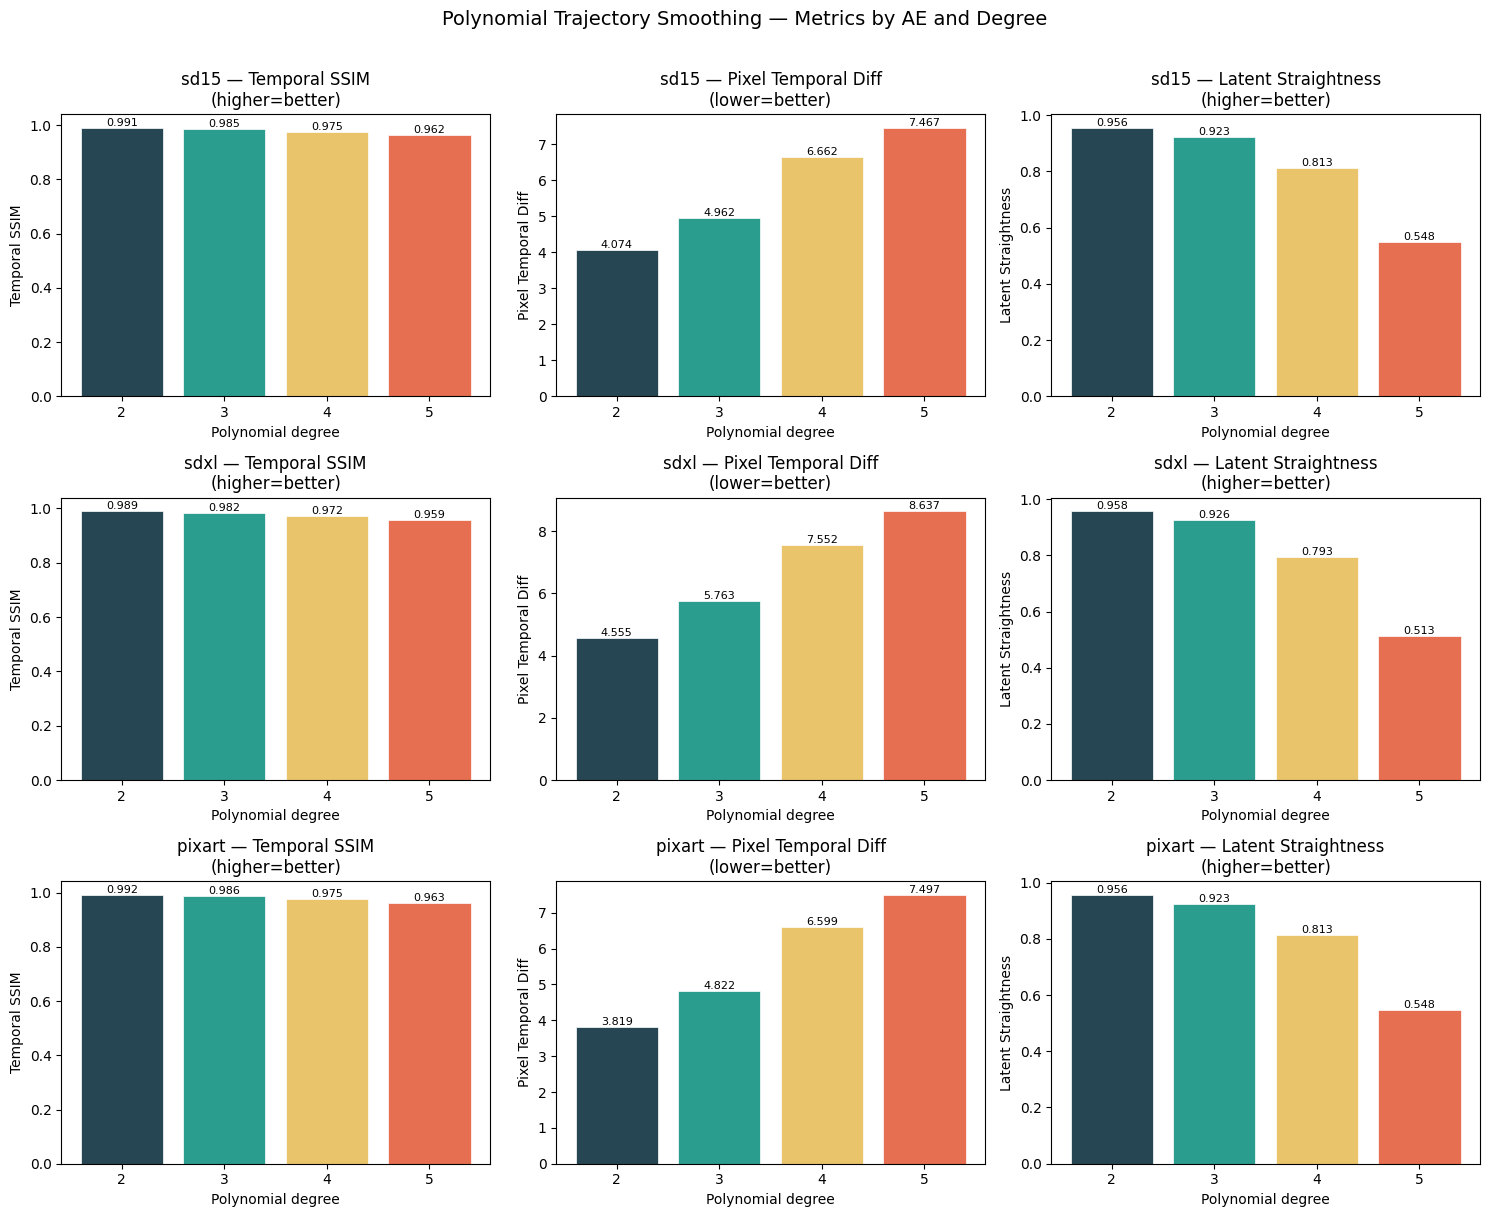

Saved → experiment-results-comp\plots\metrics_bars.png


In [15]:
# ============================================================
# CELL 7 — Plot 1: Metrics bar charts per AE (SSIM / PTD / Straightness)
# ============================================================

ae_names  = list(AE_CONFIGS.keys())
degrees   = POLY_DEGREES
colors    = ["#264653", "#2a9d8f", "#e9c46a", "#e76f51"]

fig, axes = plt.subplots(len(ae_names), 3, figsize=(15, 4 * len(ae_names)))
fig.suptitle("Polynomial Trajectory Smoothing — Metrics by AE and Degree", fontsize=14, y=1.01)

metric_keys  = ["mean_ssim",          "mean_ptd",           "latent_straightness"]
metric_labels= ["Temporal SSIM\n(higher=better)",
                "Pixel Temporal Diff\n(lower=better)",
                "Latent Straightness\n(higher=better)"]

for r_idx, ae_name in enumerate(ae_names):
    for c_idx, (key, label) in enumerate(zip(metric_keys, metric_labels)):
        ax = axes[r_idx][c_idx]
        vals = [all_results[ae_name][d][key] for d in degrees]
        bars = ax.bar([str(d) for d in degrees], vals, color=colors, edgecolor="white", linewidth=0.5)
        ax.set_xlabel("Polynomial degree")
        ax.set_title(f"{ae_name} — {label}")
        ax.set_ylabel(label.split("\n")[0])
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f"{v:.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plot1_path = os.path.join(OUT_ROOT, "plots", "metrics_bars.png")
fig.savefig(plot1_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {plot1_path}")


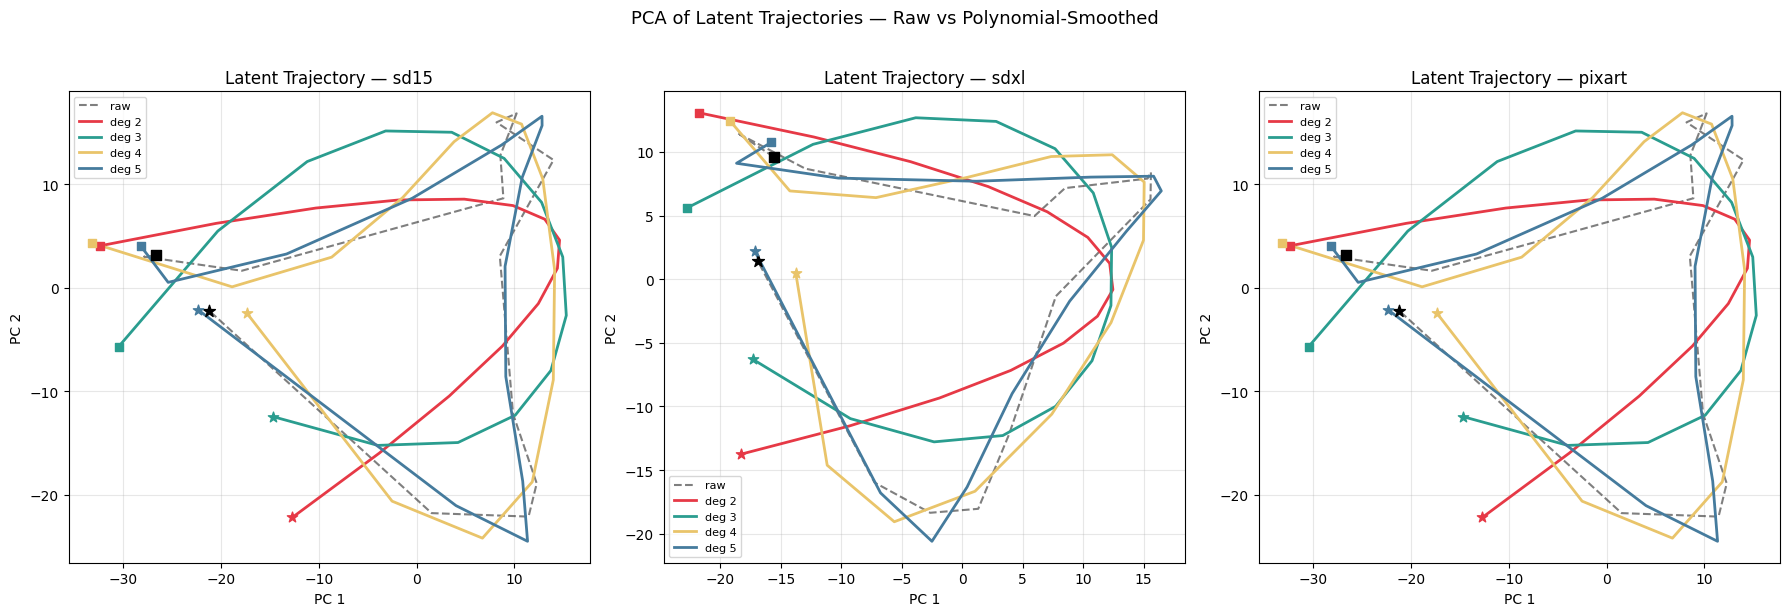

Saved → experiment-results-comp\plots\latent_trajectories_pca.png


In [17]:
# ============================================================
# CELL 8 — Plot 2: Latent trajectory PCA (raw vs smoothed degrees)
# One subplot per AE.
# ============================================================

fig, axes = plt.subplots(1, len(ae_names), figsize=(6 * len(ae_names), 6))
if len(ae_names) == 1:
    axes = [axes]

for ax, ae_name in zip(axes, ae_names):
    ax.set_title(f"Latent Trajectory — {ae_name}", fontsize=12)
    ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")

    # Raw trajectory - cast to float32 before converting to numpy
    raw_lat = all_latents[ae_name].float().reshape(NUM_FRAMES, -1).numpy()
    combined = raw_lat.copy()
    
    for d in POLY_DEGREES:
        # Cast smoothed latents to float32 here as well
        sm = all_smoothed[ae_name][d].float().reshape(NUM_FRAMES, -1).numpy()
        combined = np.concatenate([combined, sm], axis=0)
        
    # Fit PCA on combined to get shared axes
    centered = combined - combined.mean(axis=0, keepdims=True)
    _, _, vh = np.linalg.svd(centered, full_matrices=False)
    pc = vh[:2].T  # (D, 2)

    raw_2d = (raw_lat - combined.mean(axis=0)) @ pc
    ax.plot(raw_2d[:, 0], raw_2d[:, 1], "k--", lw=1.5, alpha=0.5, label="raw")
    ax.scatter(raw_2d[0, 0], raw_2d[0, 1], marker="s", s=60, color="black", zorder=5)
    ax.scatter(raw_2d[-1, 0], raw_2d[-1, 1], marker="*", s=80, color="black", zorder=5)

    for d in POLY_DEGREES:
        sm_lat = all_smoothed[ae_name][d].reshape(NUM_FRAMES, -1).numpy()
        sm_2d  = (sm_lat - combined.mean(axis=0)) @ pc
        col    = DEGREE_COLORS[d]
        ax.plot(sm_2d[:, 0], sm_2d[:, 1], color=col, lw=2, label=f"deg {d}")
        ax.scatter(sm_2d[0, 0], sm_2d[0, 1], marker="s", s=40, color=col, zorder=5)
        ax.scatter(sm_2d[-1, 0], sm_2d[-1, 1], marker="*", s=60, color=col, zorder=5)

    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("PCA of Latent Trajectories — Raw vs Polynomial-Smoothed", y=1.02, fontsize=13)
plt.tight_layout()
plot2_path = os.path.join(OUT_ROOT, "plots", "latent_trajectories_pca.png")
fig.savefig(plot2_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {plot2_path}")


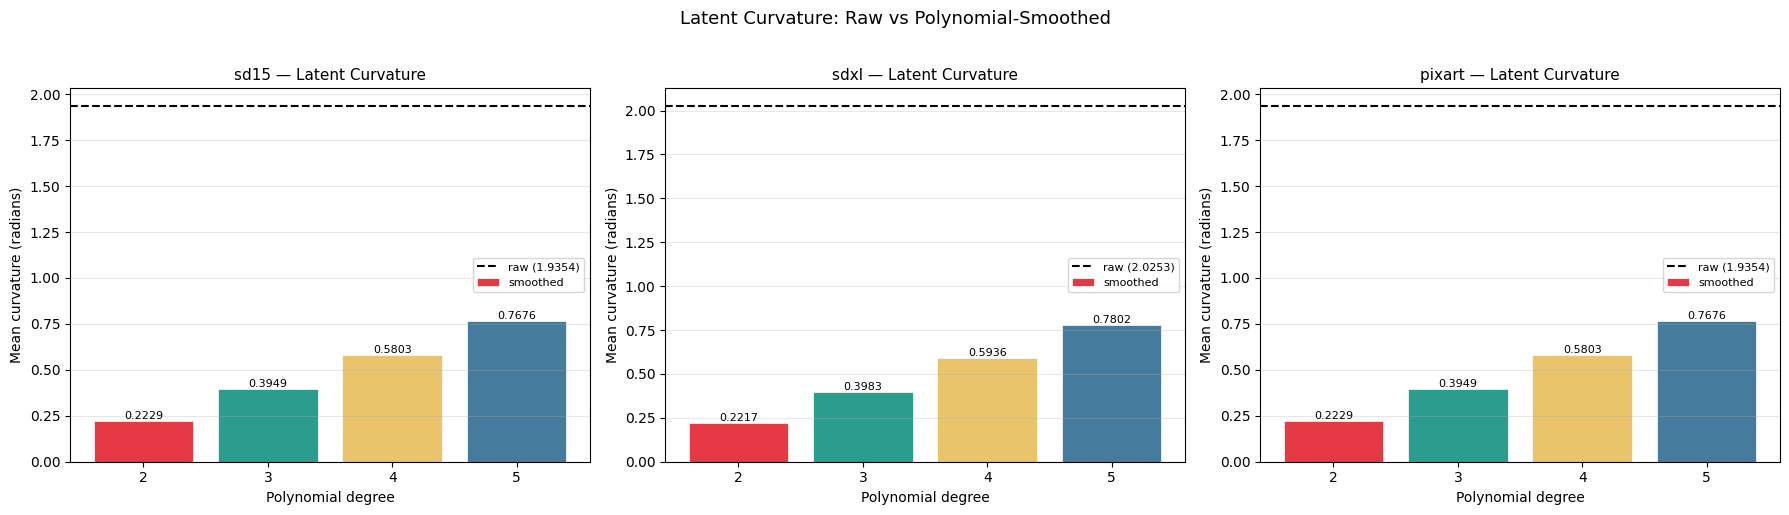

Saved → experiment-results-comp\plots\curvature_reduction.png


In [18]:
# ============================================================
# CELL 9 — Plot 3: Curvature reduction — raw vs smoothed per degree
# ============================================================

fig, axes = plt.subplots(1, len(ae_names), figsize=(6 * len(ae_names), 5), sharey=False)
if len(ae_names) == 1:
    axes = [axes]

for ax, ae_name in zip(axes, ae_names):
    raw_curv = all_results[ae_name][POLY_DEGREES[0]]["latent_curvature_raw"]
    smooth_curvs = [all_results[ae_name][d]["latent_curvature_smoothed"] for d in POLY_DEGREES]
    x_labels = [str(d) for d in POLY_DEGREES]

    bars = ax.bar(x_labels, smooth_curvs, color=[DEGREE_COLORS[d] for d in POLY_DEGREES],
                  edgecolor="white", linewidth=0.5, label="smoothed")
    ax.axhline(raw_curv, color="black", linestyle="--", lw=1.5, label=f"raw ({raw_curv:.4f})")

    for bar, v in zip(bars, smooth_curvs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f"{v:.4f}", ha="center", va="bottom", fontsize=8)

    ax.set_title(f"{ae_name} — Latent Curvature", fontsize=11)
    ax.set_xlabel("Polynomial degree")
    ax.set_ylabel("Mean curvature (radians)")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Latent Curvature: Raw vs Polynomial-Smoothed", fontsize=13, y=1.02)
plt.tight_layout()
plot3_path = os.path.join(OUT_ROOT, "plots", "curvature_reduction.png")
fig.savefig(plot3_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {plot3_path}")


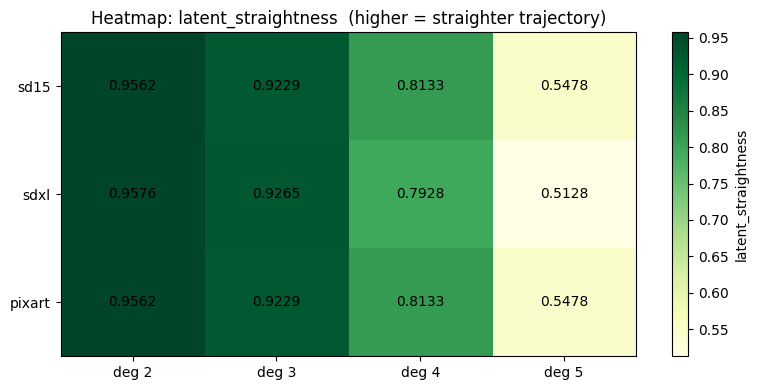

Saved → experiment-results-comp\plots\heatmap_straightness.png


In [19]:
# ============================================================
# CELL 10 — Plot 4: Cross-AE comparison (heatmap table)
# ============================================================

import matplotlib.colors as mcolors

metric_to_plot = "latent_straightness"   # pick the headline metric

table_data = np.array(
    [[all_results[ae][d][metric_to_plot] for d in POLY_DEGREES]
     for ae in ae_names]
)

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(table_data, cmap="YlGn", aspect="auto")
plt.colorbar(im, ax=ax, label=metric_to_plot)

ax.set_xticks(range(len(POLY_DEGREES)))
ax.set_xticklabels([f"deg {d}" for d in POLY_DEGREES])
ax.set_yticks(range(len(ae_names)))
ax.set_yticklabels(ae_names)
ax.set_title(f"Heatmap: {metric_to_plot}  (higher = straighter trajectory)", fontsize=12)

for i in range(len(ae_names)):
    for j in range(len(POLY_DEGREES)):
        ax.text(j, i, f"{table_data[i, j]:.4f}", ha="center", va="center",
                fontsize=10, color="black")

plt.tight_layout()
plot4_path = os.path.join(OUT_ROOT, "plots", "heatmap_straightness.png")
fig.savefig(plot4_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {plot4_path}")


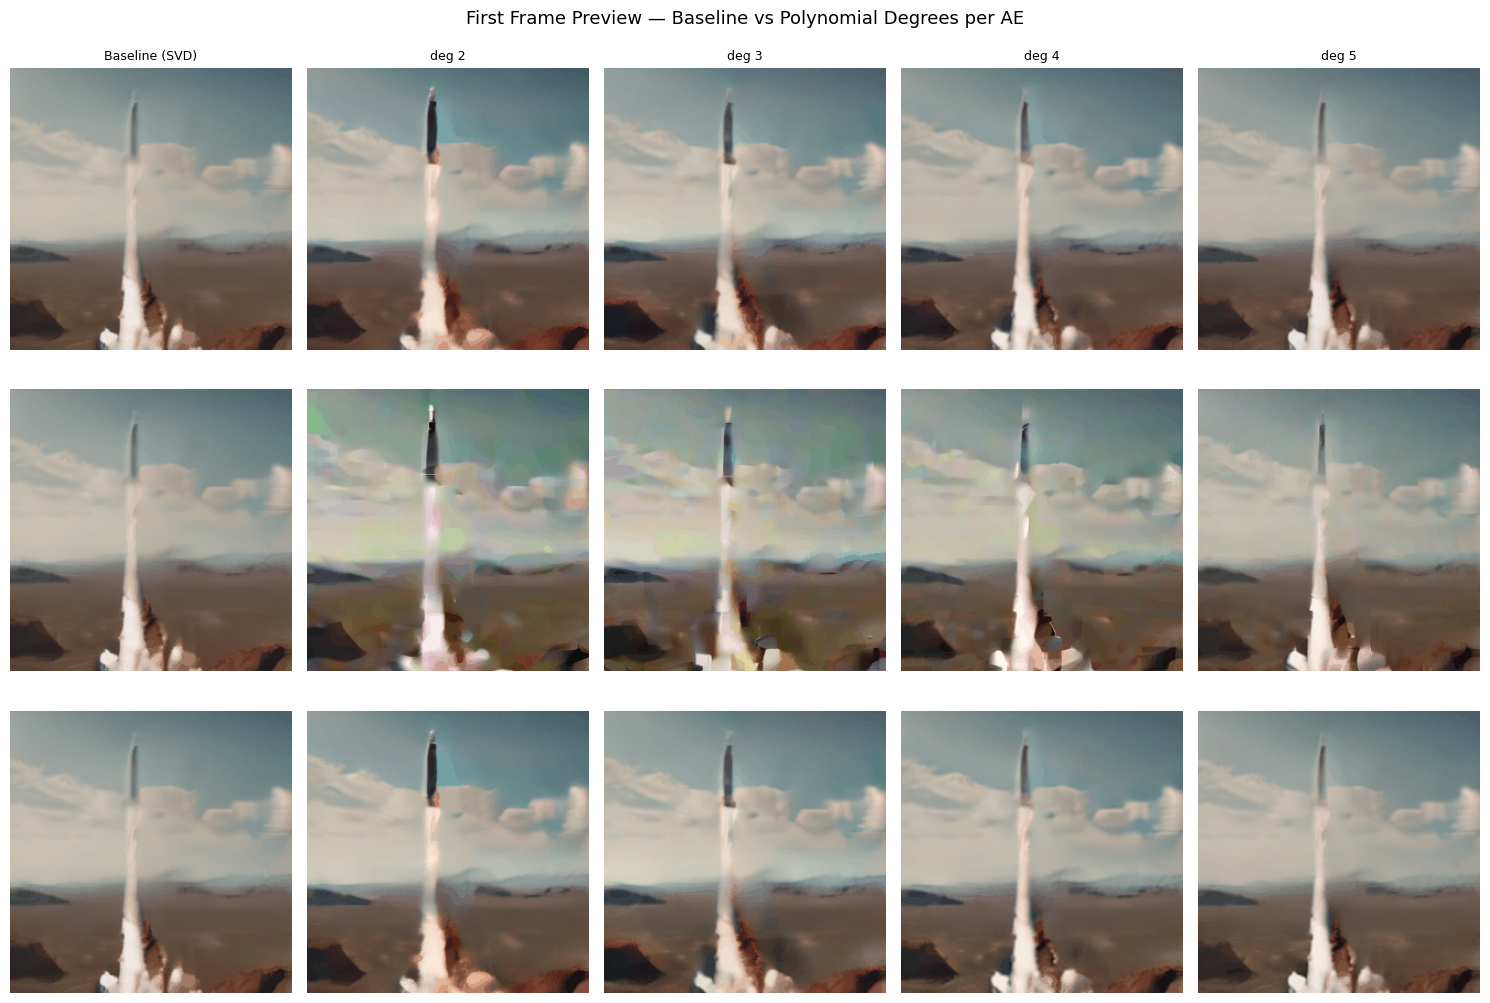

Saved → experiment-results-comp\plots\frame_previews.png


In [20]:
# ============================================================
# CELL 11 — Plot 5: GIF frame-grid preview (first frame of each config)
# ============================================================

# Reload first frame of every GIF for a visual overview
from PIL import ImageSequence

def first_frame(gif_path):
    with Image.open(gif_path) as g:
        return g.convert("RGB").copy()

n_deg = len(POLY_DEGREES)
n_ae  = len(ae_names)

fig, axes = plt.subplots(n_ae, n_deg + 1, figsize=(3 * (n_deg + 1), 3.5 * n_ae))
fig.suptitle("First Frame Preview — Baseline vs Polynomial Degrees per AE", fontsize=13)

for r, ae_name in enumerate(ae_names):
    # baseline column
    axes[r][0].imshow(first_frame(baseline_gif))
    axes[r][0].set_title("Baseline (SVD)" if r == 0 else "", fontsize=9)
    axes[r][0].set_ylabel(ae_name, fontsize=10)
    axes[r][0].axis("off")

    for c, d in enumerate(POLY_DEGREES):
        gif_path = os.path.join(OUT_ROOT, "gifs", f"{ae_name}_poly_deg{d}.gif")
        axes[r][c + 1].imshow(first_frame(gif_path))
        axes[r][c + 1].set_title(f"deg {d}" if r == 0 else "", fontsize=9)
        axes[r][c + 1].axis("off")

plt.tight_layout()
plot5_path = os.path.join(OUT_ROOT, "plots", "frame_previews.png")
fig.savefig(plot5_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {plot5_path}")


In [21]:
# ============================================================
# CELL 12 — Final summary & output listing
# ============================================================

print("\n" + "="*60)
print(" EXPERIMENT SUMMARY")
print("="*60)
print(f" Frames generated by SVD-XT : {NUM_FRAMES}")
print(f" Resolution                 : {HEIGHT}×{WIDTH}")
print(f" AEs tested                 : {ae_names}")
print(f" Polynomial degrees         : {POLY_DEGREES}")
print(f" Total GIFs produced        : {len(ae_names) * len(POLY_DEGREES) + 1}  (incl. baseline)")
print()

# Best config per AE
print(" Best degree per AE (highest latent_straightness):")
for ae_name in ae_names:
    best_deg = max(POLY_DEGREES, key=lambda d: all_results[ae_name][d]["latent_straightness"])
    best_val = all_results[ae_name][best_deg]["latent_straightness"]
    print(f"   {ae_name:<8} → degree {best_deg}  (straightness={best_val:.4f})")

print()
print(" Output files:")
for root, dirs, files in os.walk(OUT_ROOT):
    level = root.replace(OUT_ROOT, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    sub_indent = "  " * (level + 1)
    for f in sorted(files):
        fpath = os.path.join(root, f)
        kb = os.path.getsize(fpath) / 1024
        print(f"{sub_indent}{f}  ({kb:.1f} KB)")



 EXPERIMENT SUMMARY
 Frames generated by SVD-XT : 14
 Resolution                 : 256×256
 AEs tested                 : ['sd15', 'sdxl', 'pixart']
 Polynomial degrees         : [2, 3, 4, 5]
 Total GIFs produced        : 13  (incl. baseline)

 Best degree per AE (highest latent_straightness):
   sd15     → degree 2  (straightness=0.9562)
   sdxl     → degree 2  (straightness=0.9576)
   pixart   → degree 2  (straightness=0.9562)

 Output files:
experiment-results-comp/
  seed_image.png  (62.7 KB)
  gifs/
    baseline.gif  (407.1 KB)
    pixart_poly_deg2.gif  (380.3 KB)
    pixart_poly_deg3.gif  (390.5 KB)
    pixart_poly_deg4.gif  (400.3 KB)
    pixart_poly_deg5.gif  (411.7 KB)
    sd15_poly_deg2.gif  (383.5 KB)
    sd15_poly_deg3.gif  (392.4 KB)
    sd15_poly_deg4.gif  (401.1 KB)
    sd15_poly_deg5.gif  (411.9 KB)
    sdxl_poly_deg2.gif  (400.8 KB)
    sdxl_poly_deg3.gif  (403.9 KB)
    sdxl_poly_deg4.gif  (407.2 KB)
    sdxl_poly_deg5.gif  (409.1 KB)
  metrics/
    all_metrics.json  